In [1]:
import pandas as pd
fao = pd.read_csv("FAOSTAT_data.csv")
crop = pd.read_csv("Crop_recommendation.csv")

In [3]:
fao

,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code (CPC),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
0,QCL,Crops and livestock products,356,India,5312,Area harvested,1654.0,"Anise, badian, coriander, cumin, caraway, fenn...",2001,2001,ha,5.692710e+05,A,Official figure,NaN
1,QCL,Crops and livestock products,356,India,5412,Yield,1654.0,"Anise, badian, coriander, cumin, caraway, fenn...",2001,2001,kg/ha,4.303000e+02,A,Official figure,NaN
2,QCL,Crops and livestock products,356,India,5510,Production,1654.0,"Anise, badian, coriander, cumin, caraway, fenn...",2001,2001,t,2.449430e+05,A,Official figure,NaN
3,QCL,Crops and livestock products,356,India,5312,Area harvested,1654.0,"Anise, badian, coriander, cumin, caraway, fenn...",2002,2002,ha,5.470280e+05,A,Official figure,NaN
4,QCL,Crops and livestock products,356,India,5412,Yield,1654.0,"Anise, badian, coriander, cumin, caraway, fenn...",2002,2002,kg/ha,2.968000e+02,A,Official figure,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5686,QCL,Crops and livestock products,356,India,5412,Yield,111.0,Wheat,2022,2022,kg/ha,3.537300e+03,A,Official figure,NaN
5687,QCL,Crops and livestock products,356,India,5510,Production,111.0,Wheat,2022,2022,t,1.077421e+08,A,Official figure,NaN
5688,QCL,Crops and livestock products,356,India,5312,Area harvested,111.0,Wheat,2023,2023,ha,3.140072e+07,A,Official figure,NaN
5689,QCL,Crops and livestock products,356,India,5412,Yield,111.0,Wheat,2023,2023,kg/ha,3.520700e+03,A,Official figure,NaN


In [5]:
fao['Element'].unique()

array(['Area harvested', 'Yield', 'Production'], dtype=object)

In [7]:
fao['Item'].unique()

array(['Anise, badian, coriander, cumin, caraway, fennel and juniper berries, raw',
       'Apples', 'Apricots', 'Areca nuts', 'Bananas', 'Barley',
       'Beans, dry', 'Cabbages', 'Cantaloupes and other melons',
       'Carrots and turnips', 'Cashew nuts, in shell', 'Cassava, fresh',
       'Castor oil seeds', 'Cauliflowers and broccoli', 'Cherries',
       'Chick peas, dry',
       'Chillies and peppers, dry (Capsicum spp., Pimenta spp.), raw',
       'Chillies and peppers, green (Capsicum spp. and Pimenta spp.)',
       'Cocoa beans', 'Coconuts, in shell', 'Coffee, green', 'Coir, raw',
       'Cucumbers and gherkins', 'Eggplants (aubergines)', 'Figs',
       'Ginger, raw', 'Grapes', 'Green garlic',
       'Groundnuts, excluding shelled', 'Jute, raw or retted',
       'Kenaf, and other textile bast fibres, raw or retted',
       'Lemons and limes', 'Lentils, dry', 'Lettuce and chicory',
       'Linseed', 'Maize (corn)', 'Mangoes, guavas and mangosteens',
       'Millet', 'Mushrooms a

In [9]:

len(fao['Item'].unique())

85

In [11]:
fao.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5691 entries, 0 to 5690
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Domain Code       5691 non-null   object 
 1   Domain            5691 non-null   object 
 2   Area Code (M49)   5691 non-null   int64  
 3   Area              5691 non-null   object 
 4   Element Code      5691 non-null   int64  
 5   Element           5691 non-null   object 
 6   Item Code (CPC)   5691 non-null   float64
 7   Item              5691 non-null   object 
 8   Year Code         5691 non-null   int64  
 9   Year              5691 non-null   int64  
 10  Unit              5691 non-null   object 
 11  Value             5485 non-null   float64
 12  Flag              5691 non-null   object 
 13  Flag Description  5691 non-null   object 
 14  Note              102 non-null    object 
dtypes: float64(2), int64(4), object(9)
memory usage: 667.0+ KB


In [13]:

fao['Item'] = fao['Item'].str.split(',')
fao = fao.explode('Item')
fao['Item'] = fao['Item'].str.strip().str.lower()
fao['Item'] = fao['Item'].apply(lambda x: x[:-1] if x.endswith('s') else x)

In [15]:

fao = fao[fao['Element'] == 'Yield']

In [17]:
fao

,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code (CPC),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
1,QCL,Crops and livestock products,356,India,5412,Yield,1654.0,anise,2001,2001,kg/ha,430.3,A,Official figure,NaN
1,QCL,Crops and livestock products,356,India,5412,Yield,1654.0,badian,2001,2001,kg/ha,430.3,A,Official figure,NaN
1,QCL,Crops and livestock products,356,India,5412,Yield,1654.0,coriander,2001,2001,kg/ha,430.3,A,Official figure,NaN
1,QCL,Crops and livestock products,356,India,5412,Yield,1654.0,cumin,2001,2001,kg/ha,430.3,A,Official figure,NaN
1,QCL,Crops and livestock products,356,India,5412,Yield,1654.0,caraway,2001,2001,kg/ha,430.3,A,Official figure,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5677,QCL,Crops and livestock products,356,India,5412,Yield,111.0,wheat,2019,2019,kg/ha,3533.4,A,Official figure,NaN
5680,QCL,Crops and livestock products,356,India,5412,Yield,111.0,wheat,2020,2020,kg/ha,3439.8,A,Official figure,NaN
5683,QCL,Crops and livestock products,356,India,5412,Yield,111.0,wheat,2021,2021,kg/ha,3520.8,A,Official figure,NaN
5686,QCL,Crops and livestock products,356,India,5412,Yield,111.0,wheat,2022,2022,kg/ha,3537.3,A,Official figure,NaN


In [19]:
fao.shape

(2792, 15)

In [21]:
l1 = []
for i in fao['Item']:
    if i not in l1:
        l1.append(i)

l1.sort()
l1

['and other textile bast fibre',
 'anise',
 'apple',
 'apricot',
 'areca nut',
 'badian',
 'banana',
 'barley',
 'bean',
 'cabbage',
 'cantaloupes and other melon',
 'caraway',
 'cardamom',
 'carrots and turnip',
 'cashew nut',
 'cassava',
 'castor oil seed',
 'cauliflowers and broccoli',
 'cherrie',
 'chick pea',
 'chillies and pepper',
 'clementine',
 'cocoa bean',
 'coconut',
 'coffee',
 'coriander',
 'cucumbers and gherkin',
 'cumin',
 'dry',
 'dry (capsicum spp.',
 'dry (excluding dehydrated)',
 'eggplants (aubergines)',
 'excluding shelled',
 'fennel and juniper berrie',
 'fig',
 'fresh',
 'fresh n.e.c.',
 'ginger',
 'grape',
 'green',
 'green (capsicum spp. and pimenta spp.)',
 'green garlic',
 'groundnut',
 'guavas and mangosteen',
 'in shell',
 'jute',
 'kenaf',
 'lemons and lime',
 'lentil',
 'lettuce and chicory',
 'linseed',
 'mace',
 'maize (corn)',
 'mandarin',
 'mangoe',
 'millet',
 'n.e.c.',
 'natural rubber in primary form',
 'nutmeg',
 'okra',
 'onions and shallot',
 

In [23]:
len(l1)

106

In [25]:
crop

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
...,...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee


In [27]:


crop.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [29]:
crop['label'].unique()

array(['rice', 'maize', 'chickpea', 'kidneybeans', 'pigeonpeas',
       'mothbeans', 'mungbean', 'blackgram', 'lentil', 'pomegranate',
       'banana', 'mango', 'grapes', 'watermelon', 'muskmelon', 'apple',
       'orange', 'papaya', 'coconut', 'cotton', 'jute', 'coffee'],
      dtype=object)

In [31]:

len(crop['label'].unique())

22

In [33]:
crop['label'] = crop['label'].str.strip().str.lower()
crop['label'] = crop['label'].apply(lambda x: x[:-1] if x.endswith('s') else x)
     

In [35]:
l2 = []
for i in crop['label']:
    if i not in l2:
        l2.append(i)

l2.sort()
l2

['apple',
 'banana',
 'blackgram',
 'chickpea',
 'coconut',
 'coffee',
 'cotton',
 'grape',
 'jute',
 'kidneybean',
 'lentil',
 'maize',
 'mango',
 'mothbean',
 'mungbean',
 'muskmelon',
 'orange',
 'papaya',
 'pigeonpea',
 'pomegranate',
 'rice',
 'watermelon']

In [37]:
len(l2)

22

In [95]:
rename_map = {
    'chickpea': 'chick pea',
    'maize': 'maize (corn)',
    'mango': 'mangoes',
    'pigeonpea': 'pigeon pea',
    'muskmelon': 'cantaloupes and other melon'
}
     




In [97]:
crop['label'] = crop['label'].replace(rename_map)

In [99]:
merged = pd.merge(fao, crop, left_on='Item', right_on='label', how='inner')
     

In [101]:

merged

,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code (CPC),Item,Year Code,Year,...,Flag Description,Note,N,P,K,temperature,humidity,ph,rainfall,label
0,QCL,Crops and livestock products,356,India,5412,Yield,1341.0,apple,2001,2001,...,Official figure,NaN,24,128,196,22.750888,90.694892,5.521467,110.431786,apple
1,QCL,Crops and livestock products,356,India,5412,Yield,1341.0,apple,2001,2001,...,Official figure,NaN,7,144,197,23.849401,94.348150,6.133221,114.051249,apple
2,QCL,Crops and livestock products,356,India,5412,Yield,1341.0,apple,2001,2001,...,Official figure,NaN,14,128,205,22.608010,94.589006,6.226290,116.039659,apple
3,QCL,Crops and livestock products,356,India,5412,Yield,1341.0,apple,2001,2001,...,Official figure,NaN,8,120,201,21.186674,91.134357,6.321152,122.233323,apple
4,QCL,Crops and livestock products,356,India,5412,Yield,1341.0,apple,2001,2001,...,Official figure,NaN,20,129,201,23.410447,91.699133,5.587906,116.077793,apple
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36795,QCL,Crops and livestock products,356,India,5412,Yield,1221.0,watermelon,2023,2023,...,Official figure,NaN,97,12,47,25.287846,89.636679,6.765095,58.286977,watermelon
36796,QCL,Crops and livestock products,356,India,5412,Yield,1221.0,watermelon,2023,2023,...,Official figure,NaN,110,7,45,26.638386,84.695469,6.189214,48.324286,watermelon
36797,QCL,Crops and livestock products,356,India,5412,Yield,1221.0,watermelon,2023,2023,...,Official figure,NaN,96,18,50,25.331045,84.305338,6.904242,41.532187,watermelon
36798,QCL,Crops and livestock products,356,India,5412,Yield,1221.0,watermelon,2023,2023,...,Official figure,NaN,83,23,55,26.897502,83.892415,6.463271,43.971937,watermelon


In [103]:
len(merged['label'].value_counts())

16

In [105]:
merged['label'].value_counts()

label
apple                          2300
banana                         2300
cantaloupes and other melon    2300
chick pea                      2300
coconut                        2300
coffee                         2300
grape                          2300
jute                           2300
lentil                         2300
maize (corn)                   2300
mangoe                         2300
orange                         2300
papaya                         2300
pigeon pea                     2300
rice                           2300
watermelon                     2300
Name: count, dtype: int64

In [110]:
cols_to_drop = [
    'Domain Code', 'Domain', 'Area Code (M49)', 'Area',
    'Element Code','Item Code (CPC)','item',
    'Year Code', 'Year', 'Unit', 'Flag',
    'Flag Description', 'Note'
]
    

In [112]:
merged.drop(columns=[c for c in cols_to_drop if c in merged.columns],inplace=True)

In [114]:
merged

,Element,Item,Value,N,P,K,temperature,humidity,ph,rainfall,label
0,Yield,apple,5125.0,24,128,196,22.750888,90.694892,5.521467,110.431786,apple
1,Yield,apple,5125.0,7,144,197,23.849401,94.348150,6.133221,114.051249,apple
2,Yield,apple,5125.0,14,128,205,22.608010,94.589006,6.226290,116.039659,apple
3,Yield,apple,5125.0,8,120,201,21.186674,91.134357,6.321152,122.233323,apple
4,Yield,apple,5125.0,20,129,201,23.410447,91.699133,5.587906,116.077793,apple
...,...,...,...,...,...,...,...,...,...,...,...
36795,Yield,watermelon,28777.8,97,12,47,25.287846,89.636679,6.765095,58.286977,watermelon
36796,Yield,watermelon,28777.8,110,7,45,26.638386,84.695469,6.189214,48.324286,watermelon
36797,Yield,watermelon,28777.8,96,18,50,25.331045,84.305338,6.904242,41.532187,watermelon
36798,Yield,watermelon,28777.8,83,23,55,26.897502,83.892415,6.463271,43.971937,watermelon


In [116]:
final_data = merged[['Element', 'Value', 'N', 'P', 'K',
                      'temperature', 'humidity', 'ph', 'rainfall', 'label']]

print("Final dataset ready!")
     

Final dataset ready!


In [118]:
final_data

,Element,Value,N,P,K,temperature,humidity,ph,rainfall,label
0,Yield,5125.0,24,128,196,22.750888,90.694892,5.521467,110.431786,apple
1,Yield,5125.0,7,144,197,23.849401,94.348150,6.133221,114.051249,apple
2,Yield,5125.0,14,128,205,22.608010,94.589006,6.226290,116.039659,apple
3,Yield,5125.0,8,120,201,21.186674,91.134357,6.321152,122.233323,apple
4,Yield,5125.0,20,129,201,23.410447,91.699133,5.587906,116.077793,apple
...,...,...,...,...,...,...,...,...,...,...
36795,Yield,28777.8,97,12,47,25.287846,89.636679,6.765095,58.286977,watermelon
36796,Yield,28777.8,110,7,45,26.638386,84.695469,6.189214,48.324286,watermelon
36797,Yield,28777.8,96,18,50,25.331045,84.305338,6.904242,41.532187,watermelon
36798,Yield,28777.8,83,23,55,26.897502,83.892415,6.463271,43.971937,watermelon


In [120]:

final_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36800 entries, 0 to 36799
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Element      36800 non-null  object 
 1   Value        36800 non-null  float64
 2   N            36800 non-null  int64  
 3   P            36800 non-null  int64  
 4   K            36800 non-null  int64  
 5   temperature  36800 non-null  float64
 6   humidity     36800 non-null  float64
 7   ph           36800 non-null  float64
 8   rainfall     36800 non-null  float64
 9   label        36800 non-null  object 
dtypes: float64(5), int64(3), object(2)
memory usage: 2.8+ MB


In [122]:


final_data['label'].value_counts()

label
apple                          2300
banana                         2300
cantaloupes and other melon    2300
chick pea                      2300
coconut                        2300
coffee                         2300
grape                          2300
jute                           2300
lentil                         2300
maize (corn)                   2300
mangoe                         2300
orange                         2300
papaya                         2300
pigeon pea                     2300
rice                           2300
watermelon                     2300
Name: count, dtype: int64

In [ ]:
#eda processing

In [124]:


print(final_data.describe())

              Value            N             P             K   temperature  \
count  36800.000000  36800.00000  36800.000000  36800.000000  36800.000000   
mean   11219.778533     54.51875     54.918125     57.507500     25.682590   
std    12086.647608     35.92631     36.947172     56.384085      5.344668   
min      590.800000      0.00000      5.000000      5.000000      8.825675   
25%     1575.775000     24.00000     25.000000     25.000000     22.810495   
50%     6056.050000     44.00000     51.000000     40.000000     25.671126   
75%    21026.575000     88.00000     72.000000     53.000000     28.435914   
max    44328.400000    120.00000    145.000000    205.000000     43.675493   

           humidity            ph      rainfall  
count  36800.000000  36800.000000  36800.000000  
mean      73.577874      6.409264    113.429245  
std       21.310207      0.682778     59.258474  
min       14.258040      4.507524     20.211267  
25%       61.766090      5.988560     69.403720

In [126]:


print("\nMissing Values Before Handling:")
print(final_data.isnull().sum())
     


Missing Values Before Handling:
Element        0
Value          0
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64


In [128]:
print("\nDuplicate rows before drop:", final_data.duplicated().sum())
final_data = final_data.drop_duplicates()
print("Duplicate rows after drop:", final_data.duplicated().sum())


Duplicate rows before drop: 400
Duplicate rows after drop: 0


In [130]:
final_data['Element'].unique()

array(['Yield'], dtype=object)

In [132]:


final_data['label'].unique()

array(['apple', 'banana', 'cantaloupes and other melon', 'chick pea',
       'coconut', 'coffee', 'grape', 'jute', 'lentil', 'maize (corn)',
       'mangoe', 'orange', 'papaya', 'pigeon pea', 'rice', 'watermelon'],
      dtype=object)

In [134]:


len(final_data['label'].value_counts())

16

In [136]:

final_data.nunique()

Element           1
Value           362
N               120
P               117
K                73
temperature    1600
humidity       1600
ph             1600
rainfall       1600
label            16
dtype: int64

In [138]:


import matplotlib.pyplot as plt
import seaborn as sns
     

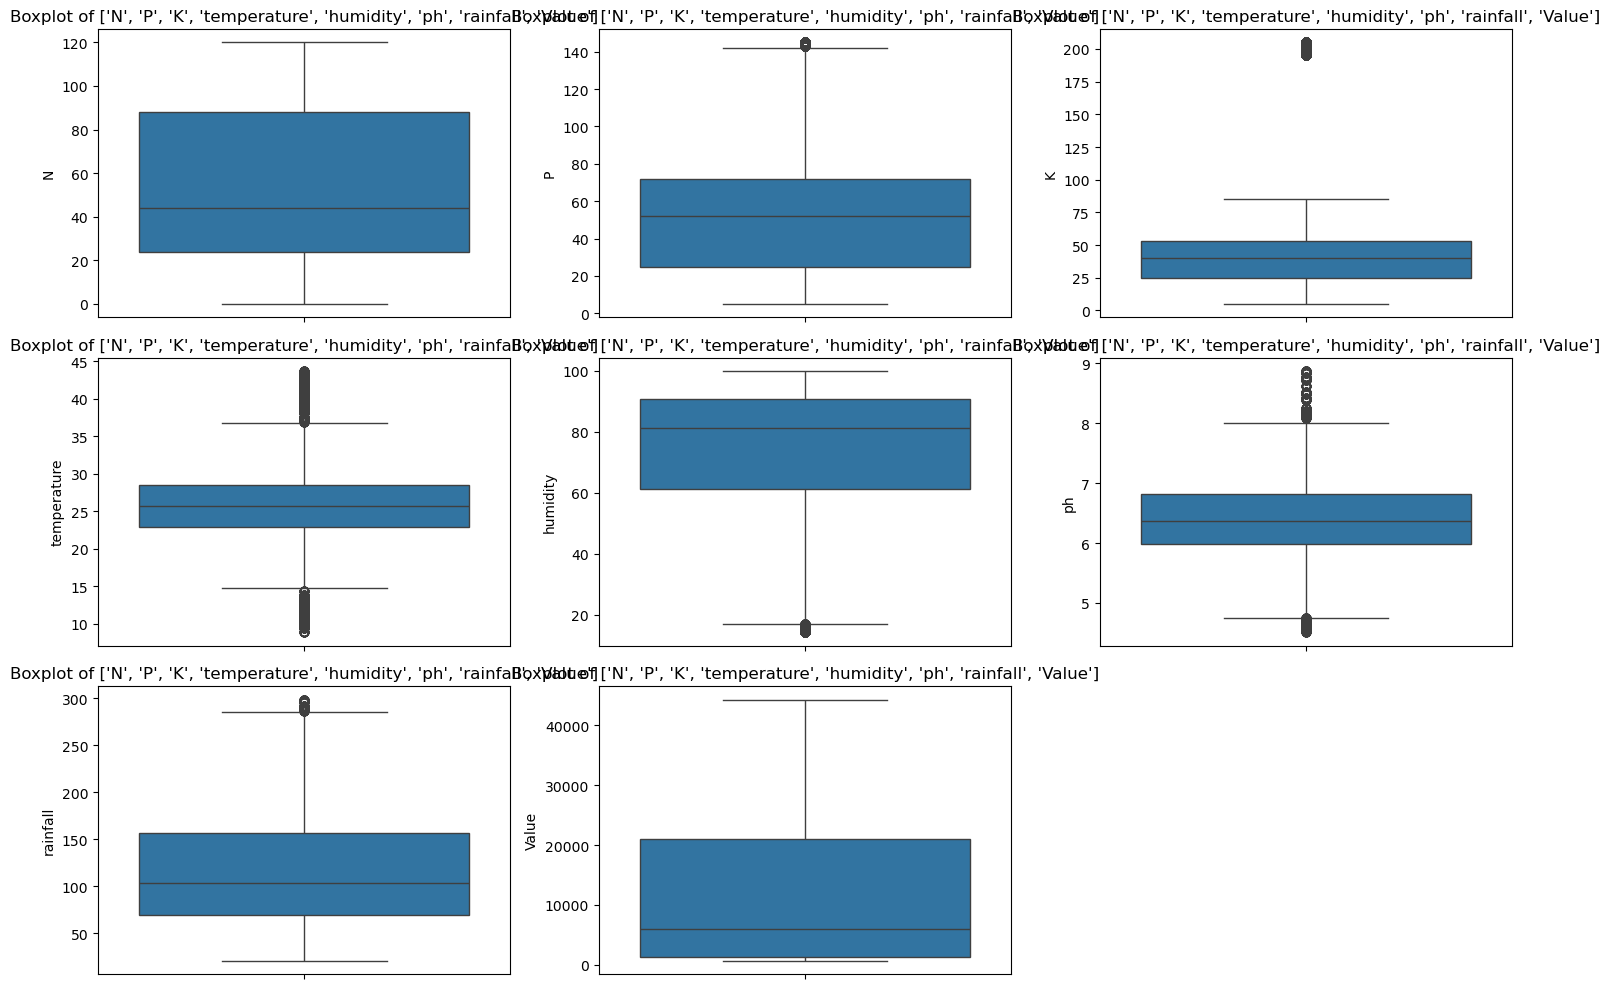

In [139]:

plt.figure(figsize=(15,10))
numeric_cols = ['N','P','K','temperature','humidity','ph','rainfall','Value']

for i, col in enumerate(numeric_cols,1):
    plt.subplot(3,3,i)
    sns.boxplot(data=final_data, y=col)
    plt.title(f"Boxplot of {numeric_cols}")

plt.tight_layout()
plt.show()


In [142]:
numeric_cols = ['N','P','K','temperature','humidity','ph','rainfall','Value']

Q1 = final_data[numeric_cols].quantile(0.25)
Q3 = final_data[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

final_clean = final_data[
    ~((final_data[numeric_cols] < (Q1 - 1.5 * IQR)) |
      (final_data[numeric_cols] > (Q3 + 1.5 * IQR))).any(axis=1)
]

print("Before:", final_data.shape)
print("After :", final_clean.shape)
print("Removed rows:", final_data.shape[0] - final_clean.shape[0])


Before: (36400, 10)
After : (28317, 10)
Removed rows: 8083


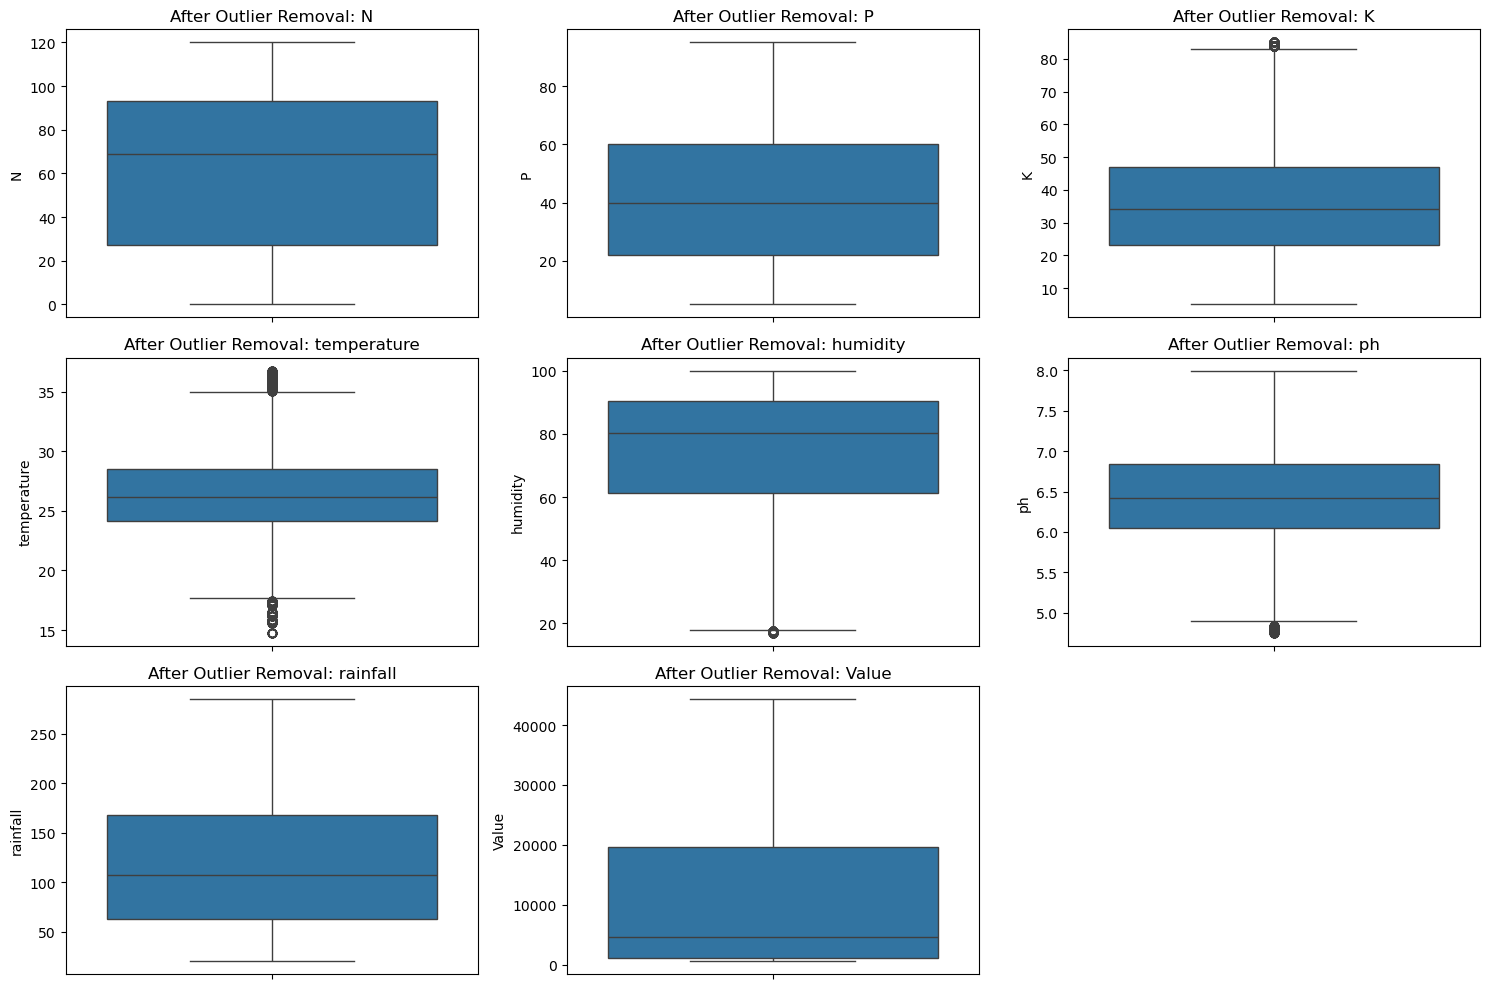

In [144]:

plt.figure(figsize=(15,10))
for i, col in enumerate(numeric_cols,1):
    plt.subplot(3,3,i)
    sns.boxplot(data=final_clean, y=col)
    plt.title(f"After Outlier Removal: {col}")

plt.tight_layout()
plt.show()

In [146]:


final_clean

,Element,Value,N,P,K,temperature,humidity,ph,rainfall,label
2300,Yield,30480.3,91,94,46,29.367924,76.249001,6.149934,92.828409,banana
2301,Yield,30480.3,105,95,50,27.333690,83.676752,5.849076,101.049479,banana
2302,Yield,30480.3,108,92,53,27.400536,82.962213,6.276800,104.937800,banana
2303,Yield,30480.3,86,76,54,29.315908,80.115857,5.926825,90.109781,banana
2304,Yield,30480.3,80,77,49,26.054330,79.396545,5.519088,113.229737,banana
...,...,...,...,...,...,...,...,...,...,...
36795,Yield,28777.8,97,12,47,25.287846,89.636679,6.765095,58.286977,watermelon
36796,Yield,28777.8,110,7,45,26.638386,84.695469,6.189214,48.324286,watermelon
36797,Yield,28777.8,96,18,50,25.331045,84.305338,6.904242,41.532187,watermelon
36798,Yield,28777.8,83,23,55,26.897502,83.892415,6.463271,43.971937,watermelon


In [148]:
final_clean['label'].unique()

array(['banana', 'cantaloupes and other melon', 'chick pea', 'coconut',
       'coffee', 'jute', 'lentil', 'maize (corn)', 'mangoe', 'orange',
       'papaya', 'pigeon pea', 'rice', 'watermelon'], dtype=object)

In [150]:

len(final_clean['label'].value_counts())

14

In [152]:
final_clean.isnull().sum()

Element        0
Value          0
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [156]:

before_crops = set(final_data['label'].unique())
after_crops = set(final_clean['label'].unique())

missing_crops = before_crops - after_crops

print("Crops BEFORE outlier removal:", sorted(before_crops))
print("\nCrops AFTER outlier removal:", sorted(after_crops))
print("\nCrops REMOVED due to outlier handling:", sorted(missing_crops))
     

Crops BEFORE outlier removal: ['apple', 'banana', 'cantaloupes and other melon', 'chick pea', 'coconut', 'coffee', 'grape', 'jute', 'lentil', 'maize (corn)', 'mangoe', 'orange', 'papaya', 'pigeon pea', 'rice', 'watermelon']

Crops AFTER outlier removal: ['banana', 'cantaloupes and other melon', 'chick pea', 'coconut', 'coffee', 'jute', 'lentil', 'maize (corn)', 'mangoe', 'orange', 'papaya', 'pigeon pea', 'rice', 'watermelon']

Crops REMOVED due to outlier handling: ['apple', 'grape']


In [158]:
final_clean.nunique()

Element           1
Value           316
N               119
P                91
K                61
temperature    1247
humidity       1247
ph             1247
rainfall       1247
label            14
dtype: int64

In [160]:


final_clean['label'].value_counts()

label
banana                         2300
coconut                        2300
coffee                         2300
jute                           2300
lentil                         2300
watermelon                     2300
cantaloupes and other melon    2200
maize (corn)                   2200
mangoe                         2116
rice                           2116
pigeon pea                     1978
orange                         1722
papaya                         1449
chick pea                       736
Name: count, dtype: int64

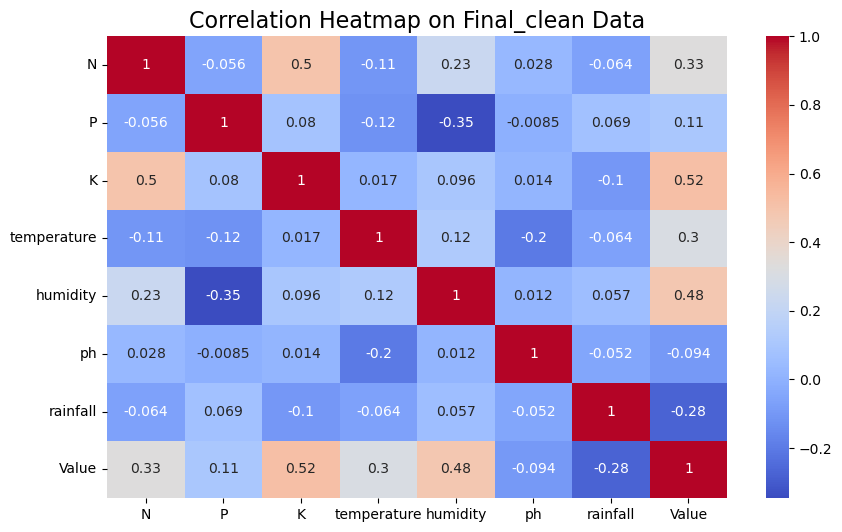

In [162]:


plt.figure(figsize=(10,6))
sns.heatmap(final_clean[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap on Final_clean Data", fontsize=16)
plt.show()

In [164]:

final_clean

,Element,Value,N,P,K,temperature,humidity,ph,rainfall,label
2300,Yield,30480.3,91,94,46,29.367924,76.249001,6.149934,92.828409,banana
2301,Yield,30480.3,105,95,50,27.333690,83.676752,5.849076,101.049479,banana
2302,Yield,30480.3,108,92,53,27.400536,82.962213,6.276800,104.937800,banana
2303,Yield,30480.3,86,76,54,29.315908,80.115857,5.926825,90.109781,banana
2304,Yield,30480.3,80,77,49,26.054330,79.396545,5.519088,113.229737,banana
...,...,...,...,...,...,...,...,...,...,...
36795,Yield,28777.8,97,12,47,25.287846,89.636679,6.765095,58.286977,watermelon
36796,Yield,28777.8,110,7,45,26.638386,84.695469,6.189214,48.324286,watermelon
36797,Yield,28777.8,96,18,50,25.331045,84.305338,6.904242,41.532187,watermelon
36798,Yield,28777.8,83,23,55,26.897502,83.892415,6.463271,43.971937,watermelon


In [166]:

final_clean = final_clean.drop(columns=['Element'], errors='ignore')
     

In [168]:
final_clean['season_index'] = final_clean['temperature'] * final_clean['humidity']

# Water Stress Index
final_clean['water_stress'] = final_clean['rainfall'] / final_clean['temperature']

In [170]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
final_clean['label_encoded'] = le.fit_transform(final_clean['label'])
final_clean[['label', 'label_encoded']].head()
final_clean
     

,Value,N,P,K,temperature,humidity,ph,rainfall,label,season_index,water_stress,label_encoded
2300,30480.3,91,94,46,29.367924,76.249001,6.149934,92.828409,banana,2239.274841,3.160877,0
2301,30480.3,105,95,50,27.333690,83.676752,5.849076,101.049479,banana,2287.194394,3.696884,0
2302,30480.3,108,92,53,27.400536,82.962213,6.276800,104.937800,banana,2273.209106,3.829772,0
2303,30480.3,86,76,54,29.315908,80.115857,5.926825,90.109781,banana,2348.669055,3.073750,0
2304,30480.3,80,77,49,26.054330,79.396545,5.519088,113.229737,banana,2068.623796,4.345909,0
...,...,...,...,...,...,...,...,...,...,...,...,...
36795,28777.8,97,12,47,25.287846,89.636679,6.765095,58.286977,watermelon,2266.718549,2.304940,13
36796,28777.8,110,7,45,26.638386,84.695469,6.189214,48.324286,watermelon,2256.150579,1.814085,13
36797,28777.8,96,18,50,25.331045,84.305338,6.904242,41.532187,watermelon,2135.542275,1.639577,13
36798,28777.8,83,23,55,26.897502,83.892415,6.463271,43.971937,watermelon,2256.496374,1.634796,13


In [172]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num_cols = [
    'N','P','K','temperature','humidity','ph','rainfall',
    'season_index','water_stress'
]

final_clean[num_cols] = scaler.fit_transform(final_clean[num_cols])
final_clean[num_cols]
     

,N,P,K,temperature,humidity,ph,rainfall,season_index,water_stress
2300,0.802079,2.200099,0.709211,0.832251,0.124126,-0.453834,-0.384922,0.515426,-0.548717
2301,1.185071,2.242736,0.972794,0.302206,0.527197,-0.936830,-0.253574,0.599219,-0.342395
2302,1.267141,2.114825,1.170481,0.319624,0.488422,-0.250164,-0.191450,0.574764,-0.291243
2303,0.665296,1.432629,1.236377,0.818697,0.333963,-0.812012,-0.428357,0.706713,-0.582255
2304,0.501157,1.475266,0.906898,-0.031146,0.294929,-1.466590,-0.058970,0.217026,-0.092568
...,...,...,...,...,...,...,...,...,...
36795,0.966218,-1.296154,0.775107,-0.230863,0.850615,0.533741,-0.936789,0.563414,-0.878190
36796,1.321854,-1.509340,0.643315,0.121036,0.582478,-0.390775,-1.095962,0.544935,-1.067133
36797,0.938862,-1.040331,0.972794,-0.219607,0.561307,0.757126,-1.204479,0.334040,-1.134306
36798,0.583226,-0.827145,1.302273,0.188552,0.538900,0.049195,-1.165499,0.545540,-1.136146


In [174]:
X = final_clean.drop(columns=['Value', 'label'])
y = final_clean['Value']

X.shape, y.shape
     

((28317, 10), (28317,))

In [176]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)
X_train.shape, X_test.shape

((22653, 10), (5664, 10))

In [178]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Linear Regression")
print("R2:", r2_score(y_test, y_pred_lr))
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))

Linear Regression
R2: 0.6580998623201146
MAE: 5771.118055983753
RMSE: 7052.939187082351


In [180]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [181]:
print("Random Forest Performance")
print("R2 Score:", r2_score(y_test, y_pred_rf))
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
     

Random Forest Performance
R2 Score: 0.9577089842304279
MAE: 1379.3319600678524
RMSE: 2480.530432585394


In [184]:

print("Train R2:", rf.score(X_train, y_train))
print("Test R2 :", rf.score(X_test, y_test))

Train R2: 0.9628929680717772
Test R2 : 0.9577089842304279


In [186]:

import pandas as pd

feature_importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance

K                0.694281
P                0.124411
season_index     0.123967
N                0.016989
label_encoded    0.016482
ph               0.013157
rainfall         0.004786
water_stress     0.002853
humidity         0.002634
temperature      0.000440
dtype: float64

In [188]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "R2": [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_rf)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf))
    ],
    "MAE": [
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, y_pred_rf)
    ]
})

results

,Model,R2,RMSE,MAE
0,Linear Regression,0.658100,7052.939187,5771.118056
1,Random Forest,0.957709,2480.530433,1379.331960


In [190]:
import joblib

joblib.dump(rf, "final_random_forest_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(le, "label_encoder.pkl")

print("Model & preprocessors saved successfully!")
     

Model & preprocessors saved successfully!
